# EDA on Retail Sales Data
### Oasis Infobyte — Data Analytics Internship | Task 1

**Objective:** Perform exploratory data analysis on retail sales data to identify sales trends, customer behaviour, product performance, and actionable business insights.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Oasis_Task1_Retail_Sales_Dataset.csv")

In [8]:
df.head()

,Order_ID,Order_Date,Customer_ID,Age,Gender,Product,Category,Quantity,Unit_Price,Sales
0,ORD100203,2024-01-01,CUST1049,56.0,Male,Headphones,Electronics,1,779.94,779.94
1,ORD100461,2024-01-01,CUST1079,39.0,Male,Headphones,Electronics,5,1130.92,5654.60
2,ORD100146,2024-01-01,CUST1227,59.0,Male,Tablet,Electronics,3,1018.95,3056.85
3,ORD100404,2024-01-02,CUST1066,55.0,Female,Perfume,Beauty,3,22.33,66.99
4,ORD100738,2024-01-02,CUST1141,56.0,Male,Hair Dryer,Beauty,1,14.77,14.77


In [9]:
df.shape

(1200, 10)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_ID     1200 non-null   object 
 1   Order_Date   1200 non-null   object 
 2   Customer_ID  1200 non-null   object 
 3   Age          1192 non-null   float64
 4   Gender       1192 non-null   object 
 5   Product      1200 non-null   object 
 6   Category     1200 non-null   object 
 7   Quantity     1200 non-null   int64  
 8   Unit_Price   1200 non-null   float64
 9   Sales        1200 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 93.9+ KB


In [11]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Age,8
Gender,8
Product,0
Category,0
Quantity,0
Unit_Price,0
Sales,0


In [12]:
df.describe()

,Age,Quantity,Unit_Price,Sales
count,1192.000000,1200.000000,1200.000000,1200.000000
mean,41.185403,2.080833,271.107617,575.468692
std,13.869792,1.157043,292.579379,797.596779
min,18.000000,1.000000,8.800000,9.880000
25%,29.000000,1.000000,80.177500,121.205000
50%,41.000000,2.000000,149.940000,264.390000
75%,54.000000,3.000000,321.027500,698.517500
max,65.000000,5.000000,1191.230000,5867.200000


## Initial Dataset Inspection

The dataset contains 1,200 retail sales records and 10 columns.
The dataset contains information about orders, customers, demographics,
products, categories, quantities, prices, and sales.

The initial inspection was performed using shape, info(), isnull(),
and describe() to understand the structure, data types, missing values,
and basic statistical characteristics of the dataset.

In [13]:
df.select_dtypes(include='number').columns

Index(['Age', 'Quantity', 'Unit_Price', 'Sales'], dtype='object')

In [14]:
df.select_dtypes(include='number').mean()

,0
Age,41.185403
Quantity,2.080833
Unit_Price,271.107617
Sales,575.468692


In [15]:
df.select_dtypes(include='number').median()

,0
Age,41.00
Quantity,2.00
Unit_Price,149.94
Sales,264.39


In [16]:
df.select_dtypes(include='number').mode().iloc[0]

,0
Age,30.00
Quantity,1.00
Unit_Price,37.03
Sales,80.28


In [17]:
df.select_dtypes(include='number').std()

,0
Age,13.869792
Quantity,1.157043
Unit_Price,292.579379
Sales,797.596779


In [18]:
numeric_df = df.select_dtypes(include='number')

stats = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Mode': numeric_df.mode().iloc[0],
    'Standard Deviation': numeric_df.std()
})

stats

,Mean,Median,Mode,Standard Deviation
Age,41.185403,41.00,30.00,13.869792
Quantity,2.080833,2.00,1.00,1.157043
Unit_Price,271.107617,149.94,37.03,292.579379
Sales,575.468692,264.39,80.28,797.596779


### Observations

- The average customer age is approximately 41 years.
- Customers purchase an average of about 2 items per order.
- Unit prices show considerable variation, with the mean price higher than the median.
- Sales values are highly variable, with the mean sales value significantly higher than the median, indicating the presence of high-value transactions.

In [19]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [20]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales

,Sales
Order_Date,
2024-01,32290.42
2024-02,24997.36
2024-03,40191.96
2024-04,36160.88
2024-05,37784.86
2024-06,25773.29
2024-07,32019.98
2024-08,31493.89
2024-09,22249.79


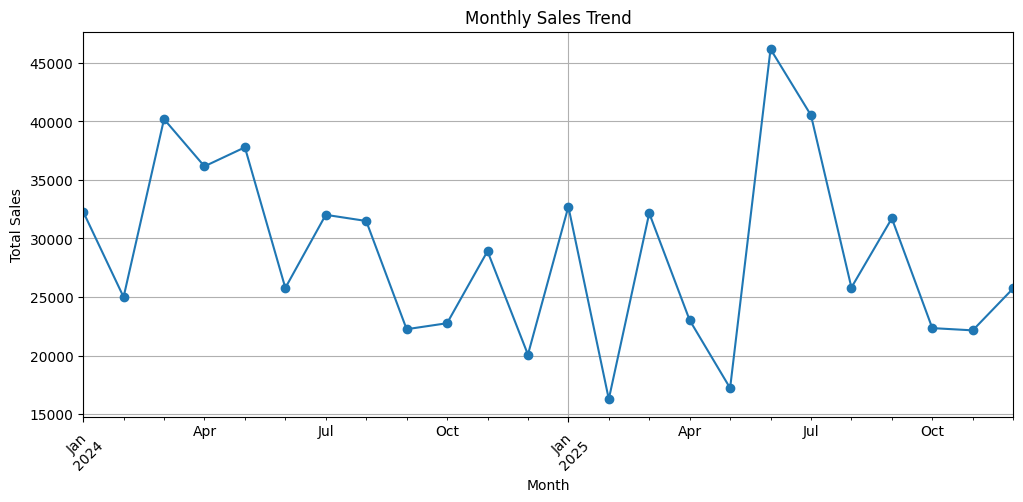

In [21]:
plt.figure(figsize=(12,5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Monthly Sales Trend — Observation

- Sales fluctuate across the months rather than following a consistent upward or downward trend.
- The highest and lowest sales months can be identified from the monthly totals.
- This variation suggests that sales performance changes considerably from month to month.

In [22]:
quarterly_sales = df.groupby(df['Order_Date'].dt.to_period('Q'))['Sales'].sum()

quarterly_sales

,Sales
Order_Date,
2024Q1,97479.74
2024Q2,99719.03
2024Q3,85763.66
2024Q4,71752.76
2025Q1,81156.32
2025Q2,86410.51
2025Q3,98051.59
2025Q4,70228.82


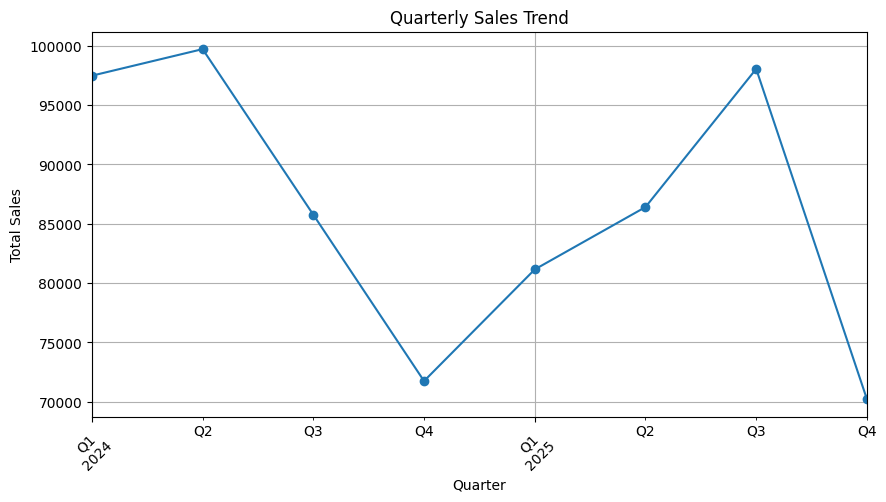

In [23]:
plt.figure(figsize=(10,5))

quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Quarterly Sales Trend — Observation

- Quarterly sales fluctuate across the analysis period.
- Some quarters generate noticeably higher revenue than others.
- This suggests that the business may experience seasonal or period-specific changes in sales performance.

In [24]:
bins = [17, 25, 35, 50, 65]
labels = ['18-25', '26-35', '36-50', '51-65']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

df['Age_Group'].value_counts().sort_index()

,count
Age_Group,
18-25,186
26-35,287
36-50,351
51-65,368


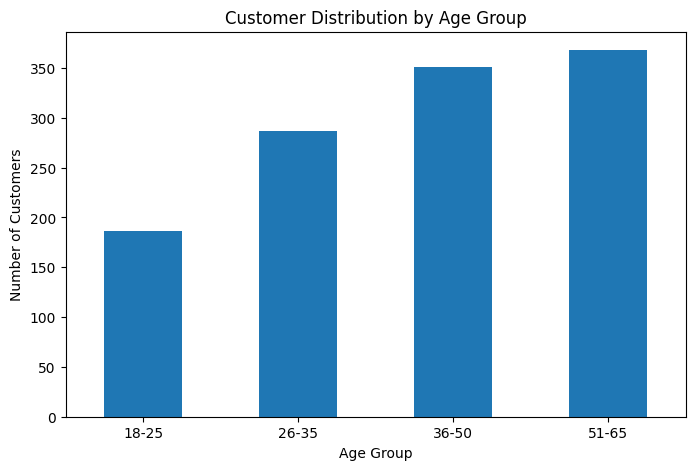

In [25]:
age_group_counts = df['Age_Group'].value_counts().sort_index()

plt.figure(figsize=(8,5))

age_group_counts.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)
plt.show()

### Age Group Analysis — Observation

- The 51–65 age group has the highest number of customer records.
- The 36–50 age group is the second largest group.
- The 18–25 age group has the lowest representation.
- Overall, the dataset contains more middle-aged and older customers than younger customers.

In [26]:
gender_counts = df['Gender'].value_counts()

gender_counts

,count
Gender,
Male,654
Female,538


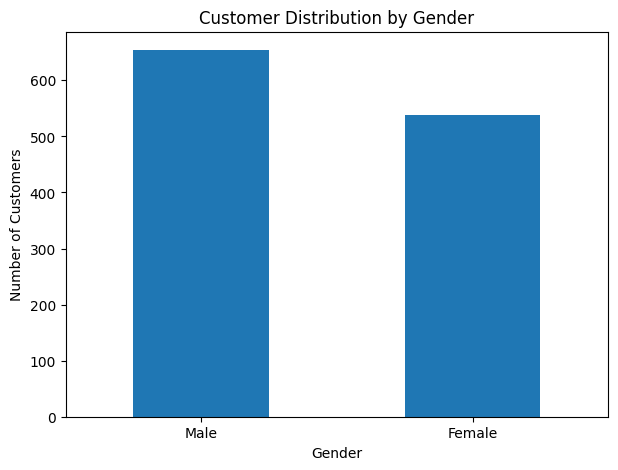

In [27]:
plt.figure(figsize=(7,5))

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)
plt.show()


### Gender Analysis — Observation

- Male customers have a higher representation than female customers in the dataset.
- However, both genders have substantial representation.
- The difference suggests a moderately male-dominated customer distribution rather than an extreme imbalance.

In [28]:
top_products = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products

,Quantity
Product,
Smartphone,148
Tablet,147
T-Shirt,144
Headphones,136
Jacket,132
Smartwatch,131
Cricket Bat,115
Laptop,113
Backpack,111


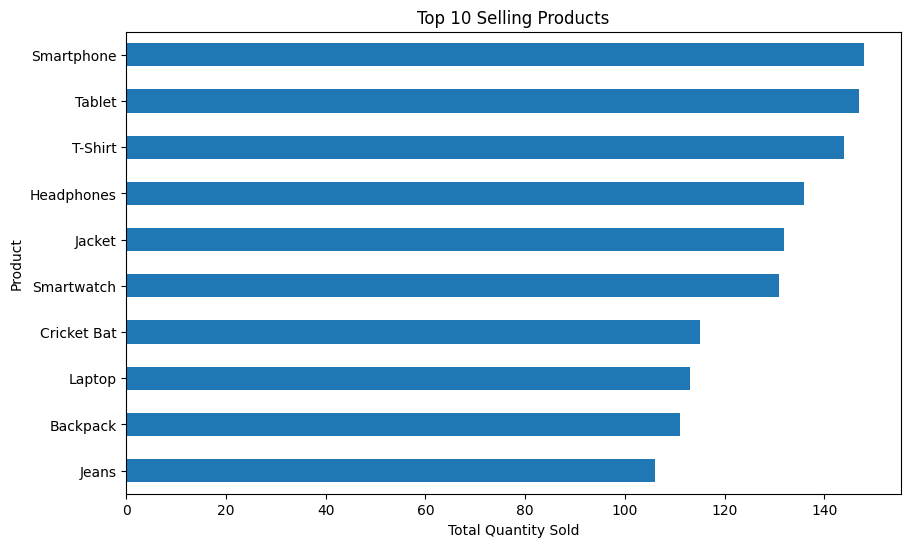

In [29]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')

plt.show()

### Top 10 Best-Selling Products — Observation

- Smartphone was the best-selling product by quantity.
- Tablet and T-Shirt were also among the strongest-performing products.
- These products represent important contributors to overall unit sales.

In [30]:
category_revenue = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_revenue

,Sales
Category,
Electronics,437804.68
Home,105788.79
Sports,67330.78
Clothing,53319.93
Beauty,26318.25


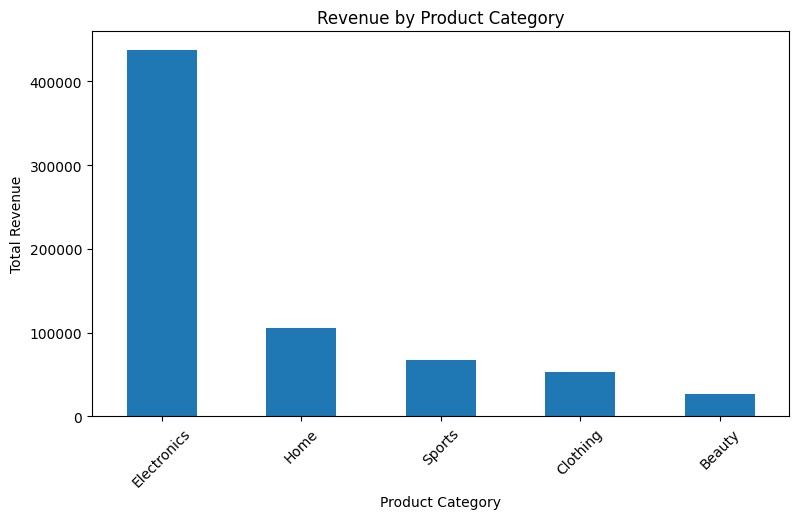

In [31]:
plt.figure(figsize=(9, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

### Revenue by Product Category — Observation

- Electronics generates by far the highest total revenue.
- Home is the second-highest revenue-generating category.
- Beauty generates the lowest revenue among the categories.
- Electronics therefore represents a major contributor to the business's overall sales revenue.

In [32]:
numeric_columns = ['Age', 'Quantity', 'Unit_Price', 'Sales']

In [33]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Age,Quantity,Unit_Price,Sales
Age,1.000000,-0.016519,-0.012179,-0.030234
Quantity,-0.016519,1.000000,0.033523,0.447410
Unit_Price,-0.012179,0.033523,1.000000,0.794266
Sales,-0.030234,0.447410,0.794266,1.000000


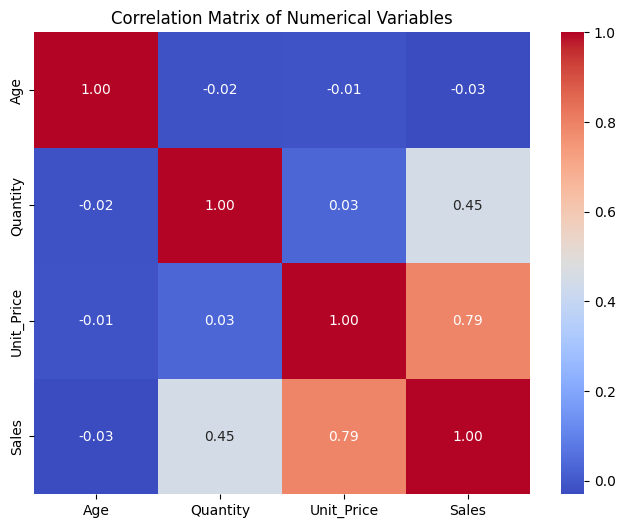

In [34]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

### Correlation Analysis — Observation

- Unit Price has a strong positive correlation with Sales (0.79).
- Quantity has a moderate positive correlation with Sales (0.45).
- Age has almost no linear relationship with Sales (-0.03).
- Among the analysed numerical variables, Unit Price has the strongest relationship with Sales.

In [35]:
age_sales = df.groupby(
    'Age_Group',
    observed=True
)['Sales'].mean()

age_sales

,Sales
Age_Group,
18-25,688.983495
26-35,537.689199
36-50,554.028291
51-65,567.469130


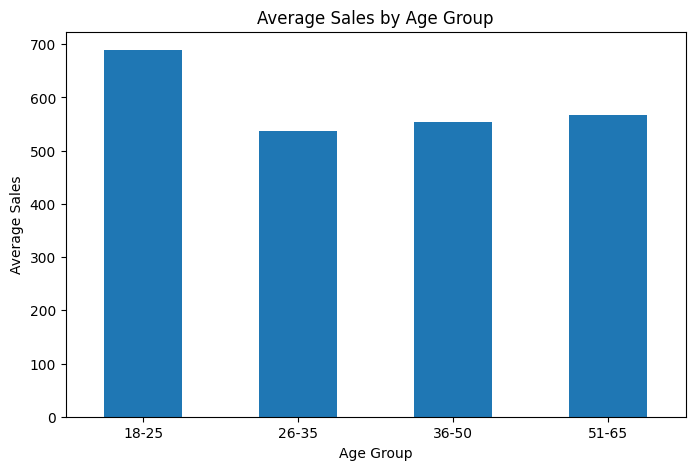

In [36]:
plt.figure(figsize=(8, 5))

age_sales.plot(kind='bar')

plt.title('Average Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)

plt.show()

### Average Sales by Age Group — Observation

- The 18–25 age group has the highest average sales per transaction.
- The 26–35 age group has the lowest average sales among the four groups.
- Although the 18–25 group had fewer transaction records in the demographic analysis, its average transaction value is higher.
- This makes the younger customer segment worth further investigation for targeted marketing.

## Business Recommendations

### 1. Prioritize High-Performing Electronics
Electronics generates substantially more revenue than the other product
categories. Smartphones and tablets are also among the best-selling products.

**Recommendation:** The business should maintain sufficient inventory of
high-demand electronics and prioritize promotions around these products to
protect and potentially increase its strongest revenue stream.

### 2. Explore the 18–25 Customer Segment
Although the 18–25 age group has fewer transaction records than the older
age groups, it has the highest average sales value per transaction.

**Recommendation:** The business could test targeted campaigns and offers
for younger customers to determine whether increasing engagement with this
segment can generate additional revenue.

### 3. Focus on Product Value and Quantity
Unit price has a strong positive correlation with sales (0.79), while
quantity has a moderate positive correlation with sales (0.45).

**Recommendation:** The business should consider strategies such as
upselling higher-value products and product bundles while monitoring whether
these strategies increase overall transaction revenue.

# Conclusion

This exploratory data analysis examined retail sales performance, customer
demographics, product performance, and relationships between numerical
variables.

The analysis showed that electronics is the dominant revenue-generating
category, with smartphones and tablets among the leading products by
quantity sold. Unit price showed the strongest positive correlation with
sales, while customer age showed almost no linear relationship with sales.

The demographic analysis also revealed that the 18–25 age group had the
highest average transaction sales despite having fewer transaction records
than the older age groups.

Based on these findings, the business could prioritize high-performing
electronics, explore targeted strategies for younger customers, and test
upselling or bundling strategies to increase transaction value.